In [16]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K

In [ ]:
# ===== CAPA LEGENDRE =====
class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim_leg = input_shape[-1]

        self.kernel_leg = self.add_weight(
            shape=(input_dim_leg * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel_leg"
        )

        if self.use_bias:
            self.bias_leg = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias_leg"
            )

    def call(self, inputs):
        # Convertimos la entrada al tipo de dato activo de la capa
        input_values = tf.cast(inputs, self.compute_dtype)

        # Valores iniciales de la recurrencia:
        # P0(x) = 1
        previous_previous_poly = tf.ones_like(input_values)

        # P1(x) = x
        previous_poly = input_values

        # Empezamos guardando el primer polinomio
        legendre_features = [previous_poly]

        # Generamos el resto de grados usando la recurrencia de Legendre
        for degree_index in range(2, self.degree + 1):
            current_degree = tf.cast(degree_index, self.compute_dtype)

            #Esto es el polinomio de Legendre pero calculado con la Recurrencia de Bonnet
            current_poly = ((2.0 * current_degree - 1.0) * input_values * previous_poly - (current_degree - 1.0) * previous_previous_poly) / current_degree

            legendre_features.append(current_poly)

            # SIguientes iteraciones
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        # Unimos todas las bases polinómicas en un solo vector
        polynomial_basis = tf.concat(legendre_features, axis=-1)

        # Proyección lineal final, equivalente a una capa densa
        output_values = tf.matmul(polynomial_basis, self.kernel_leg)

        if self.use_bias:
            output_values = tf.nn.bias_add(output_values, self.bias_leg)

        return output_values


In [18]:
# ===== FUNCIÓN DE PLOTEO =====
def plot_training_history_leg(history_leg):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_leg.history['loss'], label='Pérdida entrenamiento')
    plt.plot(history_leg.history['val_loss'], label='Pérdida validación')
    plt.title('Pérdida')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history_leg.history['accuracy'], label='Precisión entrenamiento')
    plt.plot(history_leg.history['val_accuracy'], label='Precisión validación')
    plt.title('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()



In [19]:

# ===== DATOS =====
magic_gamma_telescope_leg = fetch_ucirepo(id=159)

X_leg = magic_gamma_telescope_leg.data.features 
y_leg = magic_gamma_telescope_leg.data.targets 

X_train_leg, X_test_leg, y_train_leg, y_test_leg = train_test_split( X_leg, y_leg, test_size=0.2, random_state=42)

scaler_leg = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled_leg = scaler_leg.fit_transform(X_train_leg)
X_test_scaled_leg = scaler_leg.transform(X_test_leg)

input_dim_leg = X_train_leg.shape[1]

y_train_leg = (y_train_leg == 'g').astype(int)
y_test_leg = (y_test_leg == 'g').astype(int)


In [20]:
# ===== MODELO =====
def PolynomialDenseCreator_leg(degree_leg):
    inputPoli_leg = keras.Input(shape=(input_dim_leg,))
    
    x_leg = PolynomialLegendre(32, degree=degree_leg)(inputPoli_leg)
    x_leg = layers.Activation('swish')(x_leg)
    x_leg = layers.Dense(16, activation='swish')(x_leg)
    
    outputPoli_leg = layers.Dense(2, activation='softmax')(x_leg)
    
    model_leg = keras.Model(
        inputs=inputPoli_leg,
        outputs=outputPoli_leg,
        name=f"Polynomial_Model_Degree_{degree_leg}_leg"
    )
    
    model_leg.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_leg


In [21]:

# ===== PARÁMETROS =====
degree_leg = 4
epochs_leg = 120


def createEarlyStoppingCallback_leg(patience_leg=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_leg,
        restore_best_weights=True
    )


Entrenando Grado 4 (Legendre) ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8073 - loss: 0.4347 - val_accuracy: 0.8384 - val_loss: 0.3871
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8495 - loss: 0.3641 - val_accuracy: 0.8512 - val_loss: 0.3623
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8540 - loss: 0.3506 - val_accuracy: 0.8492 - val_loss: 0.3523
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8551 - loss: 0.3443 - val_accuracy: 0.8515 - val_loss: 0.3596
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8592 - loss: 0.3390 - val_accuracy: 0.8538 - val_loss: 0.3478
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8609 - loss: 0.3356 - val_accuracy: 0.8620 - val_loss: 0.3328
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8631 - loss: 0.3326 - val_accuracy: 0.8624 - val_loss: 0.3308
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

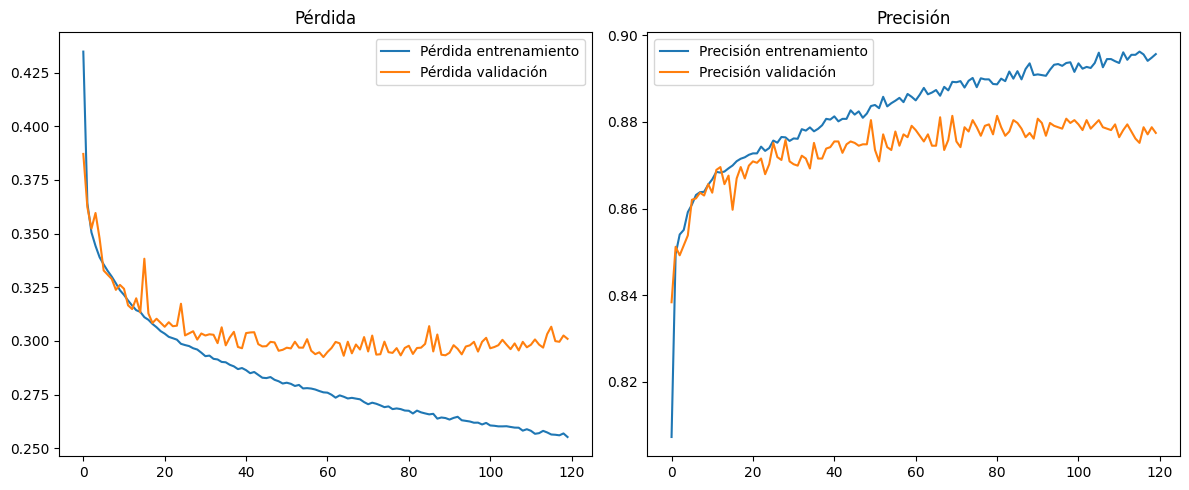

In [22]:

# ===== ENTRENAMIENTO =====
K.clear_session()

print("Entrenando Grado " + str(degree_leg) + " (Legendre) ...")

modeloTest_leg = PolynomialDenseCreator_leg(degree_leg)

history_leg = modeloTest_leg.fit(
    X_train_scaled_leg,
    y_train_leg,
    validation_split=0.2,
    epochs=epochs_leg,
    batch_size=32
)

print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree_leg} - Legendre)")

acc_leg = modeloTest_leg.evaluate(X_test_scaled_leg,y_test_leg,verbose=0)[1]

print("Accuracy en test: {:.6f}".format(acc_leg))

plot_training_history_leg(history_leg)